In [1]:
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [ ]:
import numpy as np, pandas as pd, warnings, matplotlib.pyplot as plt, seaborn as sns 
warnings.filterwarnings('ignore')
data = pd.read_csv('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Cancer.csv')
data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
data.replace({'diagnosis':{'M':1, 'B':0}}, inplace=True)

In [3]:
data = pd.read_csv('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Cancer.csv')

# Drop obvious non-features if present
drop_cols = [c for c in ["id", "ID", "Unnamed: 0", "Unnamed: 32"] if c in data.columns]
real_df = data.drop(columns=drop_cols, errors="ignore")

In [4]:
label_col = 'diagnosis' if 'diagnosis' in real_df.columns else None
y = real_df[label_col].copy() if label_col else None
X_df = real_df.drop(columns=[label_col]) if label_col else real_df

num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
X = X_df[num_cols].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=True, drop_last=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d = X_tensor.shape[1]
z_dim = 128

# Models 

In [5]:
class Generator(nn.Module):
  def __init__(self, z_dim, out_dim):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(z_dim, 256), nn.LeakyReLU(0.2),
      nn.Linear(256,256), nn.LeakyReLU(0.2),
      nn.Linear(256, out_dim), nn.Sigmoid()
      )
  def forward(self, z):
    return self.net(z)

class Discriminator(nn.Module):
  def __init__(self, in_dim):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(in_dim,256), nn.LeakyReLU(0.2),
      nn.Linear(256,256), nn.LeakyReLU(0.2),
      nn.Linear(256,1)
      )
  def forward(self, x):
    return self.net(x)

G = Generator(z_dim, d).to(device)
D = Discriminator(d).to(device)

# WGAN-GP helpers

In [6]:
def gradient_penalty(critic, real, fake):
    b = real.size(0)
    eps = torch.rand(b, 1, device=device).expand_as(real)
    interp = eps * real + (1 - eps) * fake
    interp.requires_grad_(True)
    pred = critic(interp)
    grads = torch.autograd.grad(
        outputs=pred, inputs=interp,
        grad_outputs=torch.ones_like(pred),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(b, -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp

# Optimizers
lr = 1e-4
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))

In [7]:
import matplotlib.pyplot as plt

epochs = 300
n_discriminator = 5
lambda_gp = 10.0

# --- loss history ---
hist = {
    "epoch": [],
    "D_loss": [],      # Wasserstein critic loss (without GP)
    "GP": [],          # gradient penalty
    "D_total": [],     # D_loss + lambda*GP
    "G_loss": []
}

G.train(); D.train()
for epoch in range(1, epochs + 1):
    d_loss_epoch = 0.0
    gp_epoch = 0.0
    d_total_epoch = 0.0
    g_loss_epoch = 0.0
    n_batches = 0

    for (real_batch,) in loader:
        real_batch = real_batch.to(device)
        b = real_batch.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------
        for _ in range(n_discriminator):
            z = torch.randn(b, z_dim, device=device)
            fake = G(z).detach()

            d_loss = -(D(real_batch).mean() - D(fake).mean())
            gp = gradient_penalty(D, real_batch, fake)
            d_total = d_loss + lambda_gp * gp

            opt_D.zero_grad()
            d_total.backward()
            opt_D.step()

        # -------------------------
        # Train Generator
        # -------------------------
        z = torch.randn(b, z_dim, device=device)
        fake = G(z)
        g_loss = -D(fake).mean()

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # accumulate epoch stats (use last D step values for d_loss/gp)
        d_loss_epoch += d_loss.item()
        gp_epoch += gp.item()
        d_total_epoch += d_total.item()
        g_loss_epoch += g_loss.item()
        n_batches += 1

    # average over batches
    d_loss_epoch /= n_batches
    gp_epoch /= n_batches
    d_total_epoch /= n_batches
    g_loss_epoch /= n_batches

    hist["epoch"].append(epoch)
    hist["D_loss"].append(d_loss_epoch)
    hist["GP"].append(gp_epoch)
    hist["D_total"].append(d_total_epoch)
    hist["G_loss"].append(g_loss_epoch)

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | D_loss: {d_loss_epoch:.4f} | GP: {gp_epoch:.4f} | D_total: {d_total_epoch:.4f} | G_loss: {g_loss_epoch:.4f}")


Epoch   1 | D_loss: -0.0725 | GP: 0.7397 | D_total: 7.3245 | G_loss: 0.1568
Epoch  25 | D_loss: -4.9067 | GP: 0.0446 | D_total: -4.4612 | G_loss: 1.8685
Epoch  50 | D_loss: -5.8969 | GP: 0.0584 | D_total: -5.3130 | G_loss: 0.9509
Epoch  75 | D_loss: -6.1162 | GP: 0.0627 | D_total: -5.4888 | G_loss: 0.1387
Epoch 100 | D_loss: -5.7662 | GP: 0.0600 | D_total: -5.1667 | G_loss: -0.2633
Epoch 125 | D_loss: -5.6055 | GP: 0.0567 | D_total: -5.0380 | G_loss: -0.2529
Epoch 150 | D_loss: -5.4123 | GP: 0.0530 | D_total: -4.8825 | G_loss: -0.3162
Epoch 175 | D_loss: -5.3575 | GP: 0.0521 | D_total: -4.8367 | G_loss: -0.4610
Epoch 200 | D_loss: -5.2112 | GP: 0.0509 | D_total: -4.7018 | G_loss: -0.6269
Epoch 225 | D_loss: -5.0846 | GP: 0.0491 | D_total: -4.5933 | G_loss: -0.6416
Epoch 250 | D_loss: -4.9435 | GP: 0.0450 | D_total: -4.4936 | G_loss: -0.5624
Epoch 275 | D_loss: -4.8289 | GP: 0.0442 | D_total: -4.3865 | G_loss: -0.6105
Epoch 300 | D_loss: -4.8367 | GP: 0.0443 | D_total: -4.3939 | G_loss:

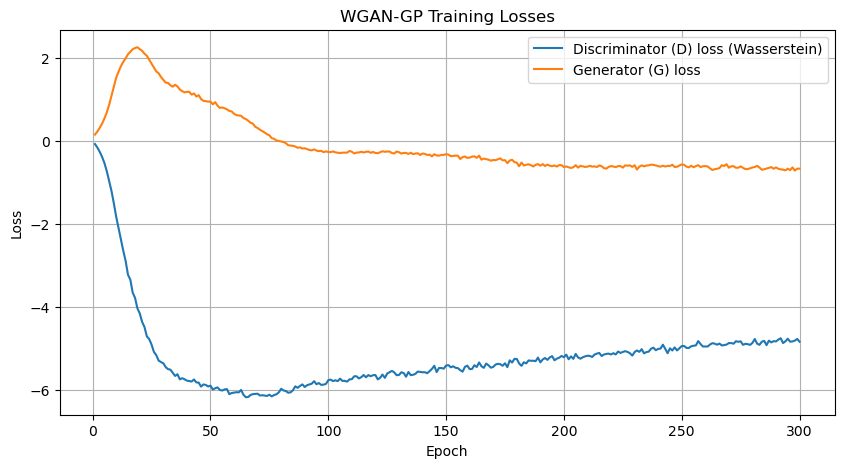

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(hist["epoch"], hist["D_loss"], label="Discriminator (D) loss (Wasserstein)")
plt.plot(hist["epoch"], hist["G_loss"], label="Generator (G) loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Training Losses")
plt.legend()
plt.grid(True)
plt.show()

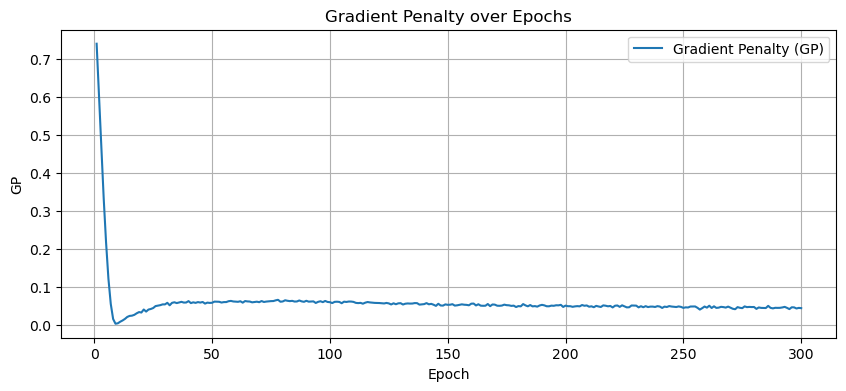

In [9]:
plt.figure(figsize=(10,4))
plt.plot(hist["epoch"], hist["GP"], label="Gradient Penalty (GP)")
plt.xlabel("Epoch")
plt.ylabel("GP")
plt.title("Gradient Penalty over Epochs")
plt.legend()
plt.grid(True)
plt.show()

## Sample + inverse scale

In [11]:
G.eval()
n_synth = 1000
with torch.no_grad():
    z = torch.randn(n_synth, z_dim, device=device)
    Xs = G(z).cpu().numpy()

X_synth = scaler.inverse_transform(Xs)
synth_df = pd.DataFrame(X_synth, columns=num_cols)

# Helper Functions

In [15]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

In [16]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_cancer(real_df, synth_df, target='diagnosis'):
    """Compute bivariate quality metrics for cancer data."""
    num_cols = [c for c in real_df.columns if c != target]
    
    # Min-Max scaling on numeric columns
    scaler = MinMaxScaler()
    
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    
    # Fit on real, transform both real and synthetic
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    
    results_corr = []
    results_target = []

    # Numeric-to-numeric: Δ-correlation
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            'var_a': a,
            'var_b': b,
            'delta_corr': abs(r_corr - s_corr)
        })
    
    # Numeric-to-target: Δ-Wasserstein between classes
    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]
        
        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
    
    return corr_df, target_df

# 1. Fidelity Metrics

## Overview
Fidelity metrics measure how well the synthetic data matches the distribution of the real data. We compute three key metrics:

1. **Kolmogorov-Smirnov (KS) Test**: Measures the maximum difference between cumulative distribution functions (CDFs) of real and synthetic data. Range [0,1] where 0 = identical distributions.

2. **Jensen-Shannon (JS) Divergence**: Measures the similarity between probability distributions. Range [0,1] where 0 = identical distributions. It's symmetric and bounded.

3. **Wasserstein Distance** (Earth Mover's Distance): Measures the minimum "cost" to transform one distribution into another. Lower values indicate better matches. We compute both scaled (normalized) and raw versions.

All metrics are computed per-feature and then aggregated to provide an overall assessment of synthetic data quality.

In [17]:
real_df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
# Prepare real_df without diagnosis column for fidelity metrics
real_df_features = real_df.drop(columns=['diagnosis'], errors='ignore')

In [ ]:
# This cell is replaced by the comprehensive fidelity_metrics_scaled function below
# The comprehensive metrics are computed in cell 22

ValueError: Expected 2D array, got scalar array instead:
array=nan.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
# Import required libraries for fidelity metrics
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def _hist_prob(x, bins=50, rng=None, eps=1e-12):
    """
    Convert a numeric array into a histogram-based probability mass function.
    
    Parameters:
    -----------
    x : array-like
        Input data array
    bins : int
        Number of bins for histogram
    rng : tuple, optional
        (min, max) range for histogram. If None, computed from data.
    eps : float
        Small epsilon to avoid zero probabilities
        
    Returns:
    --------
    p : numpy array
        Probability mass function (normalized histogram)
    rng : tuple
        (min, max) range used
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if rng is None:
        lo, hi = np.min(x), np.max(x)
        if lo == hi:
            lo, hi = lo - 0.5, hi + 0.5
        rng = (lo, hi)
    counts, _ = np.histogram(x, bins=bins, range=rng, density=False)
    p = counts.astype(float) + eps
    p /= p.sum()
    return p, rng

In [ ]:
def fidelity_metrics_scaled(real_df: pd.DataFrame,
                            synth_df: pd.DataFrame,
                            cols=None,
                            bins=50,
                            scaler_type="minmax",
                            include_raw_wasserstein=True) -> pd.DataFrame:
    if cols is None:
        cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    # ---- Fit scaler on REAL only (important!) ----
    R = real_df[cols].to_numpy(dtype=float)
    S = synth_df[cols].to_numpy(dtype=float)

    # Handle NaNs for scaling: fit on finite rows only
    # (Simple approach: replace NaN with column mean from real)
    real_col_means = np.nanmean(R, axis=0)
    R2 = np.where(np.isfinite(R), R, real_col_means)
    S2 = np.where(np.isfinite(S), S, real_col_means)

    if scaler_type.lower() == "standard":
        scaler = StandardScaler()
    else:
        scaler = MinMaxScaler()

    scaler.fit(R2)
    R_scaled = scaler.transform(R2)
    S_scaled = scaler.transform(S2)

    rows = []
    for j, c in enumerate(cols):
        r = R_scaled[:, j]
        s = S_scaled[:, j]

        r = r[np.isfinite(r)]
        s = s[np.isfinite(s)]
        if len(r) < 2 or len(s) < 2:
            continue

        # KS (unchanged by monotonic scaling, but fine to compute here)
        ks_stat, ks_p = ks_2samp(r, s, alternative="two-sided", mode="auto")
        ks_complement = 1.0 - ks_stat

        # Wasserstein on SCALED values (comparable across features)
        wdist_scaled = wasserstein_distance(r, s)

        # JS divergence on SCALED values (shared range)
        lo = float(np.nanmin(np.concatenate([r, s])))
        hi = float(np.nanmax(np.concatenate([r, s])))
        if lo == hi:
            lo, hi = lo - 0.5, hi + 0.5
        p_r, _ = _hist_prob(r, bins=bins, rng=(lo, hi))
        p_s, _ = _hist_prob(s, bins=bins, rng=(lo, hi))
        js_div = float(jensenshannon(p_r, p_s, base=2.0) ** 2)

        row = {
            "feature": c,
            "KS_stat": float(ks_stat),
            "KS_complement": float(ks_complement),
            "KS_pvalue": float(ks_p),
            "JS_divergence": js_div,
            "Wasserstein_scaled": float(wdist_scaled),
        }

        # optional raw Wasserstein (in original units)
        if include_raw_wasserstein:
            r_raw = real_df[c].to_numpy()
            s_raw = synth_df[c].to_numpy()
            r_raw = r_raw[np.isfinite(r_raw)]
            s_raw = s_raw[np.isfinite(s_raw)]
            row["Wasserstein_raw"] = float(wasserstein_distance(r_raw, s_raw))

        rows.append(row)

    out = pd.DataFrame(rows).sort_values("KS_stat", ascending=True).reset_index(drop=True)

    avg = {k: out[k].mean() for k in out.columns if k not in ["feature", "KS_pvalue"]}
    avg_row = {"feature": "AVERAGE", "KS_pvalue": np.nan, **avg}
    return pd.concat([out, pd.DataFrame([avg_row])], ignore_index=True)

In [ ]:
# Compute comprehensive fidelity metrics
metrics_df = fidelity_metrics_scaled(real_df_features, synth_df, bins=50, scaler_type="minmax")
print("Fidelity Metrics Summary:")
print("=" * 80)
metrics_df

,feature,KS_stat,KS_complement,KS_pvalue,JS_divergence,Wasserstein_scaled,Wasserstein_raw
0,smoothness_mean,0.507909,0.492091,7.569833e-86,0.431822,0.094552,0.010473
1,smoothness_worst,0.514938,0.485062,2.347248e-88,0.449924,0.106193,0.016081
2,texture_worst,0.528998,0.471002,1.679604e-93,0.608757,0.108497,4.070803
3,symmetry_mean,0.536028,0.463972,3.866139e-96,0.465060,0.077138,0.015273
4,texture_mean,0.537786,0.462214,8.334834e-97,0.623655,0.094191,2.785229
5,symmetry_worst,0.565905,0.434095,7.488728e-108,0.505817,0.073437,0.037255
6,concave points_se,0.565905,0.434095,7.488728e-108,0.566324,0.059200,0.003125
7,compactness_mean,0.572935,0.427065,9.935895e-111,0.589771,0.104417,0.034042
8,fractal_dimension_mean,0.576450,0.423550,3.474744e-112,0.489192,0.104065,0.004941
9,concave points_worst,0.576450,0.423550,3.474744e-112,0.636268,0.131954,0.038399


In [ ]:
# Visualize Fidelity Metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Check if metrics_df exists
if 'metrics_df' not in globals() or metrics_df is None or len(metrics_df) == 0:
    raise ValueError("Please run the previous cell to compute metrics_df first!")

# Filter out the AVERAGE row for visualization
metrics_plot = metrics_df[metrics_df['feature'] != 'AVERAGE'].copy()

if len(metrics_plot) == 0:
    raise ValueError("No metrics data available for visualization!")

# Determine number of features to show (max 10, or all if fewer)
n_features = min(10, len(metrics_plot))

# Create subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. KS Statistic (lower is better, closer to 0)
ax1 = axes[0, 0]
top_ks = metrics_plot.nsmallest(n_features, 'KS_stat')
if len(top_ks) > 0:
    ax1.barh(range(len(top_ks)), top_ks['KS_stat'].values)
    ax1.set_yticks(range(len(top_ks)))
    ax1.set_yticklabels(top_ks['feature'].values, fontsize=8)
    ax1.set_xlabel('KS Statistic (lower is better)', fontsize=10)
    ax1.set_title(f'Top {len(top_ks)} Features by KS Test (Best Match)', fontsize=12)
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)

# 2. JS Divergence (lower is better, closer to 0)
ax2 = axes[0, 1]
top_js = metrics_plot.nsmallest(n_features, 'JS_divergence')
if len(top_js) > 0:
    ax2.barh(range(len(top_js)), top_js['JS_divergence'].values, color='orange')
    ax2.set_yticks(range(len(top_js)))
    ax2.set_yticklabels(top_js['feature'].values, fontsize=8)
    ax2.set_xlabel('JS Divergence (lower is better)', fontsize=10)
    ax2.set_title(f'Top {len(top_js)} Features by JS Divergence (Best Match)', fontsize=12)
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)

# 3. Wasserstein Distance (scaled) - lower is better
ax3 = axes[1, 0]
top_wass = metrics_plot.nsmallest(n_features, 'Wasserstein_scaled')
if len(top_wass) > 0:
    ax3.barh(range(len(top_wass)), top_wass['Wasserstein_scaled'].values, color='green')
    ax3.set_yticks(range(len(top_wass)))
    ax3.set_yticklabels(top_wass['feature'].values, fontsize=8)
    ax3.set_xlabel('Wasserstein Distance (scaled, lower is better)', fontsize=10)
    ax3.set_title(f'Top {len(top_wass)} Features by Wasserstein Distance (Best Match)', fontsize=12)
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)

# 4. Summary statistics
ax4 = axes[1, 1]
summary_data = {
    'Metric': ['KS Statistic', 'JS Divergence', 'Wasserstein (scaled)'],
    'Mean': [
        metrics_plot['KS_stat'].mean(),
        metrics_plot['JS_divergence'].mean(),
        metrics_plot['Wasserstein_scaled'].mean()
    ],
    'Median': [
        metrics_plot['KS_stat'].median(),
        metrics_plot['JS_divergence'].median(),
        metrics_plot['Wasserstein_scaled'].median()
    ],
    'Std': [
        metrics_plot['KS_stat'].std(),
        metrics_plot['JS_divergence'].std(),
        metrics_plot['Wasserstein_scaled'].std()
    ]
}
summary_df = pd.DataFrame(summary_data)
x_pos = np.arange(len(summary_df))
width = 0.35
ax4.bar(x_pos - width/2, summary_df['Mean'], width, label='Mean', alpha=0.8)
ax4.bar(x_pos + width/2, summary_df['Median'], width, label='Median', alpha=0.8)
ax4.set_xlabel('Metric', fontsize=10)
ax4.set_ylabel('Value', fontsize=10)
ax4.set_title('Summary Statistics Across All Features', fontsize=12)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(summary_df['Metric'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("FIDELITY METRICS SUMMARY")
print("="*80)
print(f"\nAverage KS Statistic: {metrics_plot['KS_stat'].mean():.4f} (lower is better, range [0,1])")
print(f"Average JS Divergence: {metrics_plot['JS_divergence'].mean():.4f} (lower is better, range [0,1])")
print(f"Average Wasserstein Distance (scaled): {metrics_plot['Wasserstein_scaled'].mean():.4f} (lower is better)")
print(f"\nBest matching features (lowest KS statistic):")
best_n = min(5, len(metrics_plot))
print(metrics_plot.nsmallest(best_n, 'KS_stat')[['feature', 'KS_stat', 'JS_divergence', 'Wasserstein_scaled']].to_string(index=False))
print(f"\nWorst matching features (highest KS statistic):")
print(metrics_plot.nlargest(best_n, 'KS_stat')[['feature', 'KS_stat', 'JS_divergence', 'Wasserstein_scaled']].to_string(index=False))

In [ ]:
# Detailed per-feature comparison with all three metrics
if 'metrics_df' not in globals() or metrics_df is None or len(metrics_df) == 0:
    raise ValueError("Please run the previous cell to compute metrics_df first!")

print("="*100)
print("DETAILED FIDELITY METRICS - All Features")
print("="*100)
print("\nMetrics Explanation:")
print("  - KS_stat: Kolmogorov-Smirnov statistic (0=identical, 1=maximally different)")
print("  - JS_divergence: Jensen-Shannon divergence (0=identical, 1=maximally different)")
print("  - Wasserstein_scaled: Earth mover's distance on scaled data (lower=better)")
print("  - KS_pvalue: p-value from KS test (higher=more similar distributions)")
print("\n" + "-"*100)

# Display full metrics table
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

display_df = metrics_df.copy()
display_df = display_df.round(6)
print(display_df.to_string(index=False))

# Reset display options
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')


In [ ]:
# Distribution comparison plots for top 5 worst and best features
# Check required variables exist
if 'metrics_plot' not in globals() or metrics_plot is None or len(metrics_plot) == 0:
    raise ValueError("Please run the previous cells to compute metrics first!")
if 'real_df_features' not in globals() or real_df_features is None:
    raise ValueError("real_df_features not found! Please run cell 18.")
if 'synth_df' not in globals() or synth_df is None:
    raise ValueError("synth_df not found! Please run cell 12 to generate synthetic data.")

# Determine number of features to plot (max 5)
n_plot = min(5, len(metrics_plot))
if n_plot == 0:
    raise ValueError("No features available for plotting!")

# Get worst and best features by KS statistic
worst_features = metrics_plot.nlargest(n_plot, 'KS_stat')['feature'].tolist()
best_features = metrics_plot.nsmallest(n_plot, 'KS_stat')['feature'].tolist()

fig, axes = plt.subplots(2, n_plot, figsize=(4*n_plot, 8))
if n_plot == 1:
    axes = axes.reshape(2, 1)

# Plot worst features
for idx, feat in enumerate(worst_features):
    ax = axes[0, idx]
    if feat in real_df_features.columns and feat in synth_df.columns:
        real_vals = real_df_features[feat].dropna()
        synth_vals = synth_df[feat].dropna()
        
        if len(real_vals) > 0 and len(synth_vals) > 0:
            ax.hist(real_vals, bins=30, alpha=0.6, label='Real', density=True, color='blue')
            ax.hist(synth_vals, bins=30, alpha=0.6, label='Synthetic', density=True, color='red')
            ks_val = metrics_plot[metrics_plot["feature"]==feat]["KS_stat"].values[0]
            ax.set_title(f'{feat}\n(KS={ks_val:.3f})', fontsize=9)
            ax.set_xlabel('Value', fontsize=8)
            ax.set_ylabel('Density', fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{feat}\n(No data)', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Feature not found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{feat}\n(Not found)', fontsize=9)

axes[0, 0].set_ylabel(f'Worst {n_plot} Features\n(Density)', fontsize=10, fontweight='bold')

# Plot best features
for idx, feat in enumerate(best_features):
    ax = axes[1, idx]
    if feat in real_df_features.columns and feat in synth_df.columns:
        real_vals = real_df_features[feat].dropna()
        synth_vals = synth_df[feat].dropna()
        
        if len(real_vals) > 0 and len(synth_vals) > 0:
            ax.hist(real_vals, bins=30, alpha=0.6, label='Real', density=True, color='blue')
            ax.hist(synth_vals, bins=30, alpha=0.6, label='Synthetic', density=True, color='red')
            ks_val = metrics_plot[metrics_plot["feature"]==feat]["KS_stat"].values[0]
            ax.set_title(f'{feat}\n(KS={ks_val:.3f})', fontsize=9)
            ax.set_xlabel('Value', fontsize=8)
            ax.set_ylabel('Density', fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{feat}\n(No data)', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Feature not found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{feat}\n(Not found)', fontsize=9)

axes[1, 0].set_ylabel(f'Best {n_plot} Features\n(Density)', fontsize=10, fontweight='bold')

plt.suptitle('Distribution Comparison: Real vs Synthetic Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Export metrics to CSV for further analysis
if 'metrics_df' not in globals() or metrics_df is None or len(metrics_df) == 0:
    raise ValueError("Please run the previous cell to compute metrics_df first!")

if 'metrics_plot' not in globals():
    metrics_plot = metrics_df[metrics_df['feature'] != 'AVERAGE'].copy()

try:
    metrics_df.to_csv('fidelity_metrics_wgan_gp.csv', index=False)
    print("Fidelity metrics exported to 'fidelity_metrics_wgan_gp.csv'")
except Exception as e:
    print(f"Warning: Could not export to CSV: {e}")

# Create a summary report
if len(metrics_plot) > 0:
    summary_report = {
        'Metric': ['KS Statistic', 'JS Divergence', 'Wasserstein Distance (scaled)'],
        'Mean': [
            metrics_plot['KS_stat'].mean(),
            metrics_plot['JS_divergence'].mean(),
            metrics_plot['Wasserstein_scaled'].mean()
        ],
        'Median': [
            metrics_plot['KS_stat'].median(),
            metrics_plot['JS_divergence'].median(),
            metrics_plot['Wasserstein_scaled'].median()
        ],
        'Std': [
            metrics_plot['KS_stat'].std(),
            metrics_plot['JS_divergence'].std(),
            metrics_plot['Wasserstein_scaled'].std()
        ],
        'Min': [
            metrics_plot['KS_stat'].min(),
            metrics_plot['JS_divergence'].min(),
            metrics_plot['Wasserstein_scaled'].min()
        ],
        'Max': [
            metrics_plot['KS_stat'].max(),
            metrics_plot['JS_divergence'].max(),
            metrics_plot['Wasserstein_scaled'].max()
        ]
    }

    summary_df = pd.DataFrame(summary_report)
    print("\n" + "="*80)
    print("COMPREHENSIVE SUMMARY REPORT")
    print("="*80)
    print(summary_df.to_string(index=False))
    print("\n" + "="*80)
    print("Interpretation:")
    print("  - Lower values indicate better fidelity (synthetic data matches real data better)")
    print("  - KS Statistic and JS Divergence are bounded [0,1]")
    print("  - Wasserstein Distance is unbounded but scaled for comparability")
    print("="*80)
else:
    print("No metrics data available for summary report.")
